<h1 style="text-align:center; color:green; font-size:48px;">
DHNx PROJECT - STEP 2
</h1>

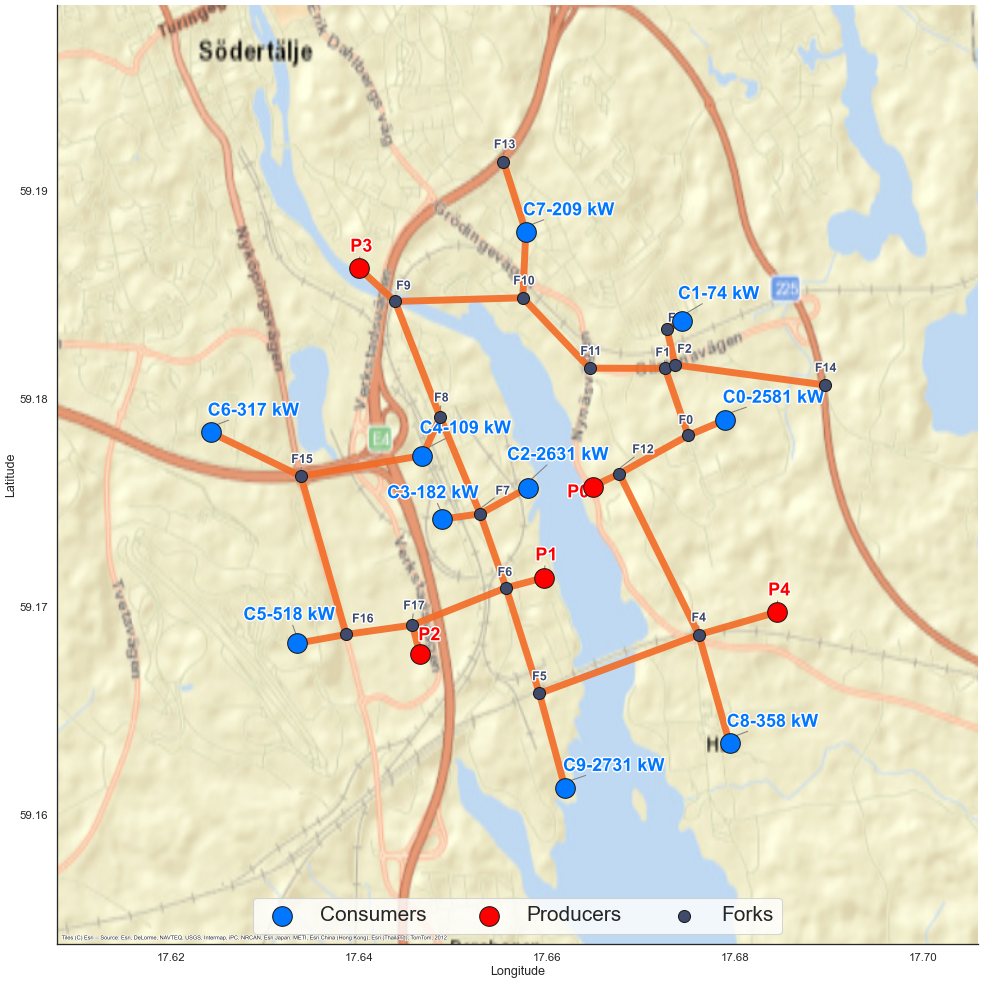

In [1]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import contextily as ctx
from DHNx_gen_map import plot_dhn_map

network = dhnx.network.ThermalNetwork()
network = network.from_csv_folder(r"../2_inputs/2_step_twn_data")
invest_opt = dhnx.input_output.load_invest_options(r"../2_inputs/2_step_invest_data")

fig, ax = plot_dhn_map(network)
plt.show()




<h1 style="text-align:center; color:green; font-size:48px;">
OPTIMIZE THE NETWORK
</h1>

In [2]:
network.optimize_investment(invest_options=invest_opt,  solver='gurobi')


c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\network\nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(


Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires 2026-10-30
Read LP format model from file C:\Users\ardia\AppData\Local\Temp\tmph7ddl1mh.pyomo.lp
Reading time = 0.04 seconds
x1: 5541 rows, 4901 columns, 12857 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 5541 rows, 4901 columns and 12857 nonzeros
Model fingerprint: 0xa89baff5
Variable types: 4289 continuous, 612 integer (612 binary)
Coefficient statistics:
  Matrix range     [3e-03, 9e+03]
  Objective range  [3e+00, 2e+06]
  Bounds range     [1e+00, 9e+03]
  RHS range        [7e+01, 3e+03]
Presolve removed 4516 rows and 3375 columns
Presolve time: 0.01s
Presolved: 1025 rows, 1526 columns, 4302 nonzeros
Variable types: 998 continuous, 528 integer 

INFO:root:Optimization successful...
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\dhnx\optimization\optimization_models.py:510: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[hp_lab + '.' + 'status'] = \
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\dhnx\optimization\optimization_models.py:486: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[hp_lab + '.' + 'dir-1'] = df['from_node'] + '-' + df['to_node']
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\dhnx\optimization\optimization_models.py:487: 

      from_node      to_node hp_type     capacity  direction          costs  \
id                                                                            
0      forks-12      forks-0  DN-150  3066.516706          1  700730.058948   
1       forks-0  consumers-0  DN-150  2666.504170          1  351216.517635   
2       forks-0      forks-1   DN-40   210.246811          1  332807.181879   
3       forks-1      forks-2   DN-32   125.348994          1   47630.506808   
4       forks-2      forks-3   DN-32   115.689165          1  157938.509098   
5       forks-3  consumers-1   DN-32    85.653635          1   77679.123411   
6       forks-1     forks-11    None     0.000000          0       0.000000   
7      forks-11     forks-10    None     0.000000          0       0.000000   
8      forks-10      forks-9   DN-65   469.660418         -1  765482.946662   
9       forks-9      forks-8    None     0.000000          0       0.000000   
10      forks-8  consumers-4   DN-32   155.834067   

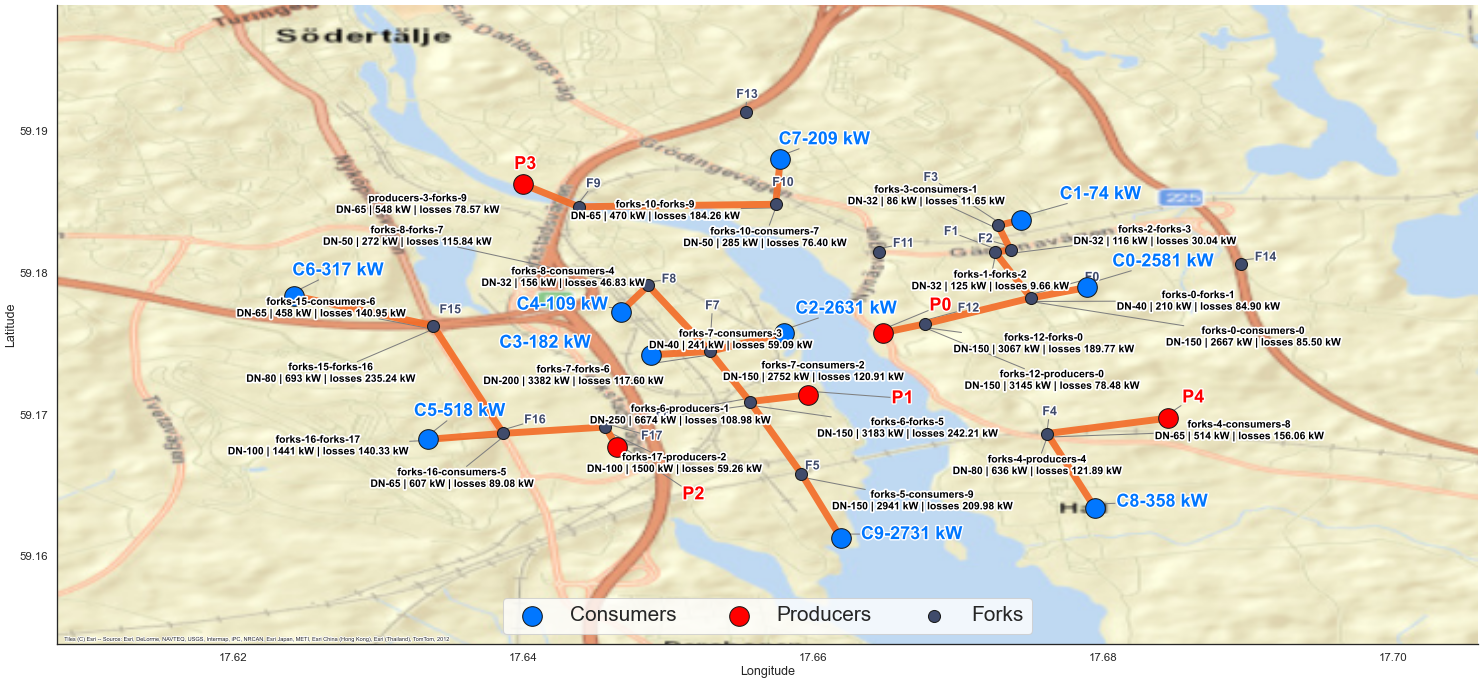

In [3]:
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])
results_edges.to_csv("../3_outputs/DHNx_step2_result.csv", index=True)

print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]
results_pipes = network.results.optimization['components']['pipes']
fig, ax = plot_dhn_map(network, results_edges=results_pipes, debug=True, figsize=(30,14),)

In [4]:
print (network.components.consumers)
print (network.components.forks)
print (network.components.producers)

          lat        lon  P_heat_max component_type
id                                                 
0   59.178979  17.678900        2581       Consumer
1   59.183727  17.674334          74       Consumer
2   59.175734  17.657970        2631       Consumer
3   59.174221  17.648840         182       Consumer
4   59.177272  17.646740         109       Consumer
5   59.168256  17.633417         518       Consumer
6   59.178389  17.624185         317       Consumer
7   59.188014  17.657734         209       Consumer
8   59.163445  17.679428         358       Consumer
9   59.161324  17.661905        2731       Consumer
          lat        lon component_type
id                                     
0   59.178237  17.675028           Fork
1   59.181461  17.672561           Fork
2   59.181632  17.673620           Fork
3   59.183360  17.672757           Fork
4   59.168671  17.676148           Fork
5   59.165848  17.659185           Fork
6   59.170922  17.655635           Fork
7   59.174472  1

=== Pipe Segment Heat Loss Report ===
 id   from_node     to_node  length hp_type    capacity         costs     losses  loss_percent
  1     forks-0 consumers-0     240  DN-150 2666.504170 351216.517635  85.504170      3.206602
  2     forks-0     forks-1     390   DN-40  210.246811 332807.181879  84.897817     40.380074
  3     forks-1     forks-2      60   DN-32  125.348994  47630.506808   9.659828      7.706347
  8    forks-10     forks-9     780   DN-65  469.660418 765482.946662 184.261037     39.232822
 25    forks-10 consumers-7     360   DN-50  285.399381 324448.545555  76.399381     26.769287
  0    forks-12     forks-0     470  DN-150 3066.516706 700730.058948 189.765726      6.188315
 19    forks-12 producers-0     190  DN-150 3145.000862 284299.500265  78.484155      2.495521
 30    forks-15    forks-16     880   DN-80  693.184396 943087.332786 235.239026     33.935996
 29    forks-15 consumers-6     610   DN-65  457.945370 597408.544125 140.945370     30.777769
 31    forks

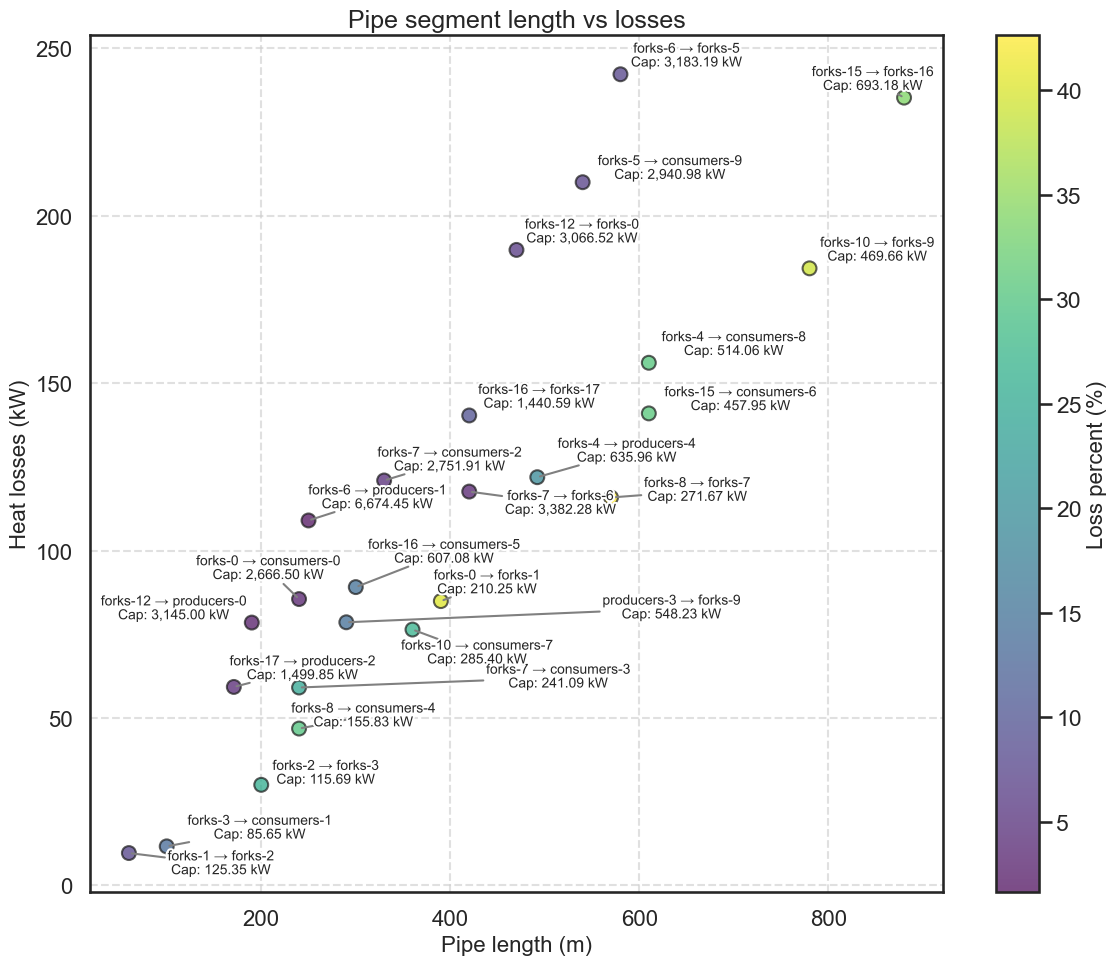

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from adjustText import adjust_text

def load_and_report_losses(csv_path):
    df = pd.read_csv(csv_path)

    # Ensure numeric
    df['losses'] = pd.to_numeric(df.get('losses', 0), errors='coerce').fillna(0)
    df['capacity'] = pd.to_numeric(df.get('capacity', 0), errors='coerce').fillna(0)

    # Compute loss percentage per segment safely
    df['loss_percent'] = df.apply(
        lambda row: (row['losses'] / row['capacity'] * 100) if row['capacity'] > 0 else np.nan,
        axis=1
    )

    # Filter only built & non-zero-loss segments
    df_losses = df[(df['capacity'] > 0) & (df['losses'] > 0)].copy()

    # Report table as before...
    df_report = df_losses[['id', 'from_node', 'to_node', 'length',
                           'hp_type', 'capacity', 'costs', 'losses', 'loss_percent']]
    df_report = df_report.sort_values('from_node', ascending=True)

    print("=== Pipe Segment Heat Loss Report ===")
    print(df_report.to_string(index=False))
    print("-------------------------------------")
    total_loss = df_losses['losses'].sum()
    mean_loss_percent = df_losses['loss_percent'].mean()
    print(f"Total heat loss (sum over segments)     : {total_loss:.2f} kW")
    print(f"Average loss percent (per segment)      : {mean_loss_percent:.2f}%")

    return df_losses, df_report

def load_and_plot_losses(csv_path):
    df = pd.read_csv(csv_path)
    df['losses'] = pd.to_numeric(df.get('losses', 0), errors='coerce').fillna(0)
    df['capacity'] = pd.to_numeric(df.get('capacity', 0), errors='coerce').fillna(0)

    df['loss_percent'] = df.apply(
        lambda r: (r['losses'] / r['capacity'] * 100) if r['capacity'] > 0 else np.nan,
        axis=1
    )

    df_losses = df[(df['capacity'] > 0) & (df['losses'] > 0)].copy()

    fig, ax = plt.subplots(figsize=(12, 10))
    sc = ax.scatter(df_losses['length'], df_losses['losses'],
                    c=df_losses['loss_percent'], cmap='viridis', edgecolor='k', s=100, alpha=0.7 )

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Loss percent (%)', fontsize=16)
    # Annotate points
    texts = []
    for _, row in df_losses.iterrows():
        label = f"{row['from_node']} → {row['to_node']}\nCap: {row['capacity']:,.2f} kW"
        texts.append(
            ax.text(row['length'], row['losses'], label, fontsize=10, fontstyle='normal',
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")])
        )

    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray'))

    ax.set_xlabel('Pipe length (m)', fontsize=16)
    ax.set_ylabel('Heat losses (kW)', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_title('Pipe segment length vs losses')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    csv_path = "../3_outputs/DHNx_step2_result.csv"  # or your actual file
    df_losses, df_report = load_and_report_losses(csv_path)
    load_and_plot_losses(csv_path)
